# Spam/Ham Classification — Complement Naive Bayes from Scratch
### Không dùng sklearn — chỉ dùng NumPy, Pandas, Matplotlib

| Bước | Nội dung |
|------|----------|
| **1** | Raw Data — Load dữ liệu |
| **2** | EDA — Phân tích khám phá dữ liệu |
| **3** | Data Processing — Xóa trùng lặp & làm sạch văn bản |
| **4** | Feature Engineering — Bag-of-Words, Train/Test Split |
| **5** | Model Training — Complement Naive Bayes (From Scratch) |
| **6** | Evaluate — Đánh giá mô hình |

In [118]:
# Step 0: Import thư viện cần thiết
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import re
from collections import Counter

pd.set_option('display.max_columns', 2)
pd.set_option('display.width', 120)

## 1. Raw Data — Load Data

In [119]:
# Step 1: Đọc file CSV spam.csv
DATA_PATH = r"D:\Hoc_tap\docker\ML\Code\Chap_2\Data\Data lad 1\spam.csv"
df = pd.read_csv(DATA_PATH, encoding='latin-1')
df = df.iloc[:, [0, 1]]
df.columns = ['label', 'text']

# Luu ban goc de trich dac trung
df['raw_text'] = df['text'].fillna('')

df['label'] = df['label'].map({'ham':0, 'spam': 1})
df.head()

,label,...,raw_text
0,0,...,"Go until jurong point, crazy.. Available only ..."
1,0,...,Ok lar... Joking wif u oni...
2,1,...,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,...,U dun say so early hor... U c already then say...
4,0,...,"Nah I don't think he goes to usf, he lives aro..."


## 2. EDA — Phân tích Khám phá Dữ liệu
> Thống kê tổng quan, kiểm tra missing values, trực quan hóa phân phối nhãn.

In [120]:
# Step 2.1: EDA — Thống kê tổng quan
print("\nINFO:")
print(df.info())

print("\nDESCRIBE:")
print(df.describe(include="all"))

print("\nMissing values:")
print(df.isna().sum())

print("\nDuplicate rows:", df.duplicated().sum())


INFO:
<class 'pandas.DataFrame'>
RangeIndex: 11172 entries, 0 to 11171
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype
---  ------    --------------  -----
 0   label     11172 non-null  int64
 1   text      11172 non-null  str  
 2   raw_text  11172 non-null  str  
dtypes: int64(1), str(2)
memory usage: 262.0 KB
None

DESCRIBE:
               label  ...                                           raw_text
count   11172.000000  ...                                              11172
unique           NaN  ...                                               6528
top              NaN  ...  Win cash prizes instantly by replying to this ...
freq             NaN  ...                                                 46
mean        0.568117  ...                                                NaN
std         0.495361  ...                                                NaN
min         0.000000  ...                                                NaN
25%         0.000000  ...      

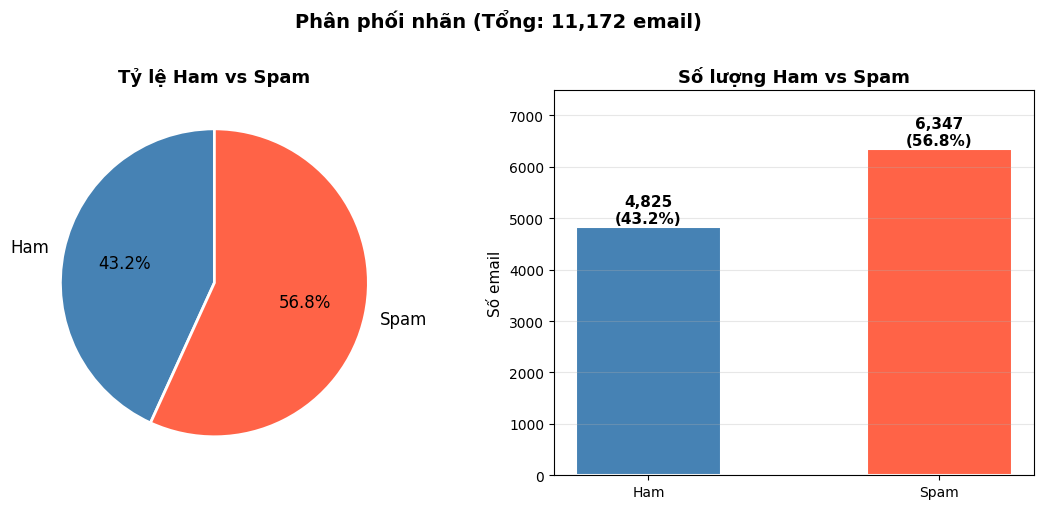

Ham : 4,825  (43.2%)
Spam: 6,347  (56.8%)


In [121]:
# Step 2.3: Visualize phân phối Ham vs Spam (%)
counts = df['label'].value_counts()
labels = ['Ham', 'Spam']
sizes  = [counts.get(0, 0), counts.get(1, 0)]
total  = sum(sizes)

colors = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Pie chart
axes[0].pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Tỷ lệ Ham vs Spam', fontsize=13, fontweight='bold')

# Bar chart với nhãn số lượng
bars = axes[1].bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, size in zip(bars, sizes):
    pct = size / total * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{size:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_title('Số lượng Ham vs Spam', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Số email', fontsize=11)
axes[1].set_ylim(0, max(sizes) * 1.18)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'Phân phối nhãn (Tổng: {total:,} email)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Ham : {sizes[0]:>5,}  ({sizes[0]/total*100:.1f}%)")
print(f"Spam: {sizes[1]:>5,}  ({sizes[1]/total*100:.1f}%)")

## 3. Data Processing — Xử lý Dữ liệu
### 3.1 Xóa Email trùng lặp (Drop Duplicates)

In [122]:
# Step 3.1: Xóa email trùng lặp (Drop Duplicates)
rows_before = len(df)

df = df.drop_duplicates(subset=['text', 'label']).reset_index(drop=True)

rows_after = len(df)
print(f"Rows trước khi xóa trùng: {rows_before}")
print(f"Rows sau khi xóa trùng:   {rows_after}")
print(f"Số dòng đã xóa:           {rows_before - rows_after}")

Rows trước khi xóa trùng: 11172
Rows sau khi xóa trùng:   6528
Số dòng đã xóa:           4644


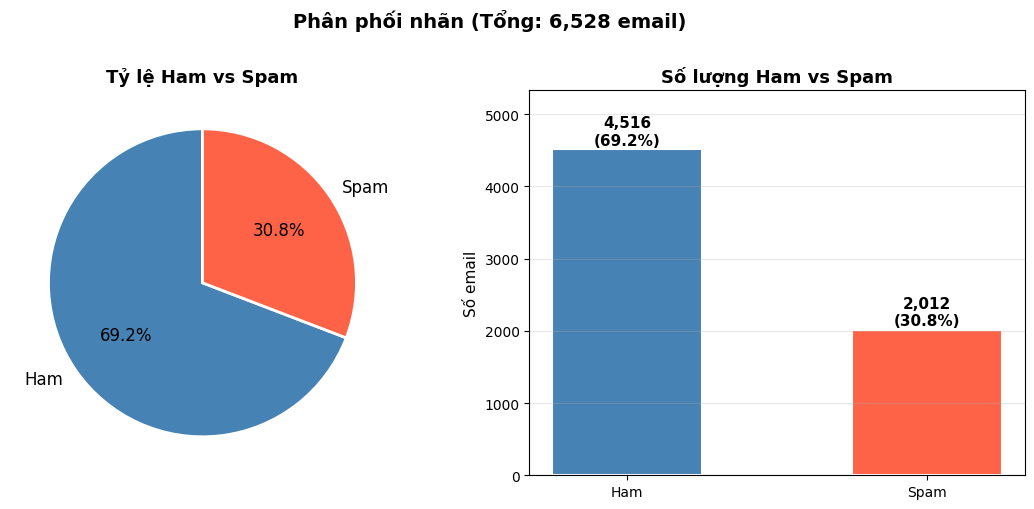

Ham : 4,516  (69.2%)
Spam: 2,012  (30.8%)


In [133]:
# Step 3.1: Visualize phân phối Ham vs Spam (%)
counts = df['label'].value_counts()
labels = ['Ham', 'Spam']
sizes  = [counts.get(0, 0), counts.get(1, 0)]
total  = sum(sizes)

colors = ['steelblue', 'tomato']

fig, axes = plt.subplots(1, 2, figsize=(11, 5))

# Pie chart
axes[0].pie(
    sizes, labels=labels, colors=colors,
    autopct='%1.1f%%', startangle=90,
    textprops={'fontsize': 12},
    wedgeprops={'edgecolor': 'white', 'linewidth': 2}
)
axes[0].set_title('Tỷ lệ Ham vs Spam', fontsize=13, fontweight='bold')

# Bar chart với nhãn số lượng
bars = axes[1].bar(labels, sizes, color=colors, edgecolor='white', linewidth=1.5, width=0.5)
for bar, size in zip(bars, sizes):
    pct = size / total * 100
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                 f'{size:,}\n({pct:.1f}%)', ha='center', va='bottom', fontsize=11, fontweight='bold')

axes[1].set_title('Số lượng Ham vs Spam', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Số email', fontsize=11)
axes[1].set_ylim(0, max(sizes) * 1.18)
axes[1].grid(axis='y', alpha=0.3)

plt.suptitle(f'Phân phối nhãn (Tổng: {total:,} email)', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

print(f"Ham : {sizes[0]:>5,}  ({sizes[0]/total*100:.1f}%)")
print(f"Spam: {sizes[1]:>5,}  ({sizes[1]/total*100:.1f}%)")

### 3.2 Làm sạch văn bản — `clean_text()`
> Chuyển về chữ thường, xóa ký tự đặc biệt, giữ lại số (digits).

In [123]:
def clean_text(text):
    if pd.isna(text):
        return ""
    text = text.lower()
    text = re.sub(r'[^a-z0-9\s]', '', text)  # giữ digits
    return text

df['text'] = df['text'].apply(clean_text)

## 4. Feature Engineering
### 4.1 Build Vocabulary & Bag-of-Words
> **Complement Naive Bayes** hoạt động trực tiếp trên word counts — không cần numerical features.
> 
> - **Vocabulary**: tập hợp tất cả các từ trong tập train (sau khi lọc min_df)
> - **Bag-of-Words (BoW)**: mỗi email → vector đếm số lần xuất hiện của từng từ trong vocab
> - `min_df=2`: loại từ chỉ xuất hiện 1 lần để giảm noise và kích thước vocab

In [124]:
class BagOfWordsVectorizer:
    """Bag-of-Words Vectorizer từ đầu, không dùng sklearn."""

    def __init__(self, min_df=2):
        """
        min_df: bỏ những từ xuất hiện trong < min_df documents
        """
        self.min_df = min_df
        self.vocab  = {}      # word → index
        self.vocab_size = 0

    def fit(self, texts):
        """Học vocabulary từ tập train."""
        doc_freq = {}
        for text in texts:
            words = set(text.split())   # set để đếm document frequency
            for w in words:
                doc_freq[w] = doc_freq.get(w, 0) + 1

        # Lọc theo min_df và sắp xếp để vocab ổn định
        filtered = sorted(w for w, cnt in doc_freq.items() if cnt >= self.min_df)
        self.vocab = {w: i for i, w in enumerate(filtered)}
        self.vocab_size = len(self.vocab)
        print(f"Vocabulary size (min_df={self.min_df}): {self.vocab_size:,} từ")

    def transform(self, texts):
        """Chuyển list texts → ma trận đếm (N, vocab_size)."""
        X = np.zeros((len(texts), self.vocab_size), dtype=np.float64)
        for i, text in enumerate(texts):
            for word in text.split():
                if word in self.vocab:
                    X[i, self.vocab[word]] += 1
        return X

    def fit_transform(self, texts):
        self.fit(texts)
        return self.transform(texts)


# Fit vectorizer chỉ trên dữ liệu train (sẽ split ở Step 4 rồi quay lại)
# → Tạm thời fit trên toàn bộ text để preview vocab
vectorizer = BagOfWordsVectorizer(min_df=2)
vectorizer.fit(df['text'].tolist())

# Hiển thị 20 từ đầu trong vocab
sample_words = list(vectorizer.vocab.keys())[:20]
print("\n20 từ đầu trong vocab:", sample_words)

Vocabulary size (min_df=2): 4,311 từ

20 từ đầu trong vocab: ['0', '008704050406', '0089my', '0121', '020603', '0207', '02072069400', '02073162414', '020903', '021', '050703', '0578', '071104', '07123456789', '07734396839', '0776xxxxxxx', '07786200117', '077xxx', '07801543489', '07808726822']


### 4.2 Train/Test Split (70/30 Stratified, From Scratch)
> Chia dữ liệu 70% train / 30% test, đảm bảo tỉ lệ Ham/Spam giữ nguyên trong cả hai tập (stratified).

In [125]:
# Step 4: Train/Test Split — 70/30 Stratified (From Scratch)
def stratified_train_test_split(X, y, test_size=0.3, random_state=42):
    """Stratified split từ đầu không dùng sklearn"""
    np.random.seed(random_state)

    unique_classes = np.unique(y)
    train_indices = []
    test_indices  = []

    for cls in unique_classes:
        cls_indices = np.where(y == cls)[0]
        np.random.shuffle(cls_indices)
        split_point = int(len(cls_indices) * (1 - test_size))
        train_indices.extend(cls_indices[:split_point])
        test_indices.extend(cls_indices[split_point:])

    train_indices = np.array(train_indices)
    test_indices  = np.array(test_indices)
    np.random.shuffle(train_indices)
    np.random.shuffle(test_indices)

    return train_indices, test_indices

# Dùng label array và text array
texts = df['text'].values
y     = df['label'].values

train_idx, test_idx = stratified_train_test_split(texts, y, test_size=0.3, random_state=42)

texts_train, texts_test = texts[train_idx], texts[test_idx]
y_train,     y_test     = y[train_idx],     y[test_idx]

print("Train size:", len(texts_train), "| Test size:", len(texts_test))
print("Train label distribution:", np.bincount(y_train))
print("Test  label distribution:", np.bincount(y_test))

Train size: 4569 | Test size: 1959
Train label distribution: [3161 1408]
Test  label distribution: [1355  604]


In [126]:
# Fit vectorizer CHỈ trên train, transform cả train và test
# (tránh data leakage)
vectorizer = BagOfWordsVectorizer(min_df=2)
X_train = vectorizer.fit_transform(texts_train)
X_test  = vectorizer.transform(texts_test)

print(f"X_train shape: {X_train.shape}")
print(f"X_test  shape: {X_test.shape}")

Vocabulary size (min_df=2): 3,524 từ
X_train shape: (4569, 3524)
X_test  shape: (1959, 3524)


## 5. Model Training — Complement Naive Bayes From Scratch

### Ý tưởng chính
**Complement Naive Bayes (CNB)** là biến thể cải tiến của Multinomial Naive Bayes, đặc biệt hiệu quả với dữ liệu **imbalanced** (mất cân bằng lớp) như spam detection.

Thay vì ước lượng $P(x_i | y = c)$, CNB ước lượng xác suất của **complement class** $\bar{c}$:

$$\hat{\theta}_{ci} = \frac{\alpha + \sum_{j: y_j \neq c} x_{ji}}{\alpha \cdot |V| + \sum_{j: y_j \neq c} \sum_k x_{jk}}$$

**Dự đoán:**
$$\hat{y} = \arg\min_c \sum_i x_i \cdot \log \hat{\theta}_{ci}$$

In [127]:
class ComplementNaiveBayes:
    """
    Complement Naive Bayes from scratch.
    Phù hợp với dữ liệu text dạng word counts (Bag-of-Words).
    """

    def __init__(self, alpha=1.0):
        """
        alpha: Laplace smoothing parameter (tránh log(0))
        """
        self.alpha     = alpha
        self.classes_  = None
        self.log_theta = None   # shape: (n_classes, vocab_size)
        self.log_prior = None   # shape: (n_classes,)

    # ------------------------------------------------------------------
    def fit(self, X, y):
        """
        X: (N, vocab_size) — word count matrix
        y: (N,) — nhãn 0/1
        """
        self.classes_ = np.unique(y)
        n_classes  = len(self.classes_)
        n_features = X.shape[1]

        self.log_theta = np.zeros((n_classes, n_features))
        self.log_prior = np.zeros(n_classes)

        for idx, c in enumerate(self.classes_):
            # Prior: tỉ lệ class trong train set
            self.log_prior[idx] = np.log(np.sum(y == c) / len(y))

            # Complement: tổng word counts của tất cả class KHÁC c
            X_complement = X[y != c]                          # (N_complement, V)
            feature_sum  = X_complement.sum(axis=0)           # (V,)

            # Smoothed log-prob
            smoothed     = feature_sum + self.alpha
            total        = smoothed.sum()
            self.log_theta[idx] = np.log(smoothed / total)   # (V,)

        print(f"Training complete — {n_classes} classes, vocab size {n_features:,}")

    # ------------------------------------------------------------------
    def _complement_scores(self, X):
        """Tính complement score cho mỗi mẫu: (N, n_classes)"""
        # X @ log_theta.T  →  (N, n_classes)
        return X @ self.log_theta.T

    def predict_proba(self, X):
        """
        Trả về xác suất class 1 (spam) bằng cách softmax hóa âm complement score.
        CNB gốc không cho xác suất trực tiếp — dùng softmin trên complement scores.
        """
        scores   = self._complement_scores(X)        # (N, 2)
        neg_scores = -scores                          # flip: score nhỏ hơn → xác suất cao hơn
        # Stable softmax
        neg_scores -= neg_scores.max(axis=1, keepdims=True)
        exp_scores = np.exp(neg_scores)
        proba = exp_scores / exp_scores.sum(axis=1, keepdims=True)
        return proba[:, 1]   # xác suất class 1 (spam)

    def predict(self, X, threshold=0.5):
        """Dự đoán nhãn dựa trên threshold."""
        return (self.predict_proba(X) >= threshold).astype(int)

### Huấn luyện mô hình
> CNB không cần StandardScaler vì model hoạt động trực tiếp trên word counts không âm.  
> Laplace smoothing (`alpha=1.0`) giúp ổn định xác suất.

In [128]:
# Step 6: Train Complement Naive Bayes
model = ComplementNaiveBayes(alpha=1.0)
model.fit(X_train, y_train)

# Dự đoán với threshold mặc định 0.5
preds = model.predict(X_test, threshold=0.5)

print(f"\nSố mẫu test: {len(y_test)}")
print(f"Dự đoán spam: {preds.sum()} / {(y_test==1).sum()} thực tế")

Training complete — 2 classes, vocab size 3,524

Số mẫu test: 1959
Dự đoán spam: 623 / 604 thực tế


## 6. Evaluate — Đánh giá mô hình

In [129]:
# Step 7: Tính Accuracy, Precision, Recall, F1 và Confusion Matrix
def confusion_matrix(y_true, y_pred):
    tp = np.sum((y_true == 1) & (y_pred == 1))
    tn = np.sum((y_true == 0) & (y_pred == 0))
    fp = np.sum((y_true == 0) & (y_pred == 1))
    fn = np.sum((y_true == 1) & (y_pred == 0))
    return tp, tn, fp, fn

tp, tn, fp, fn = confusion_matrix(y_test, preds)
accuracy  = (tp + tn) / (tp + tn + fp + fn)
precision = tp / (tp + fp + 1e-9)
recall    = tp / (tp + fn + 1e-9)
f1        = 2 * precision * recall / (precision + recall + 1e-9)

print("Accuracy: ",  round(accuracy,  4))
print("Precision:",  round(precision, 4))
print("Recall:   ",  round(recall,    4))
print("F1-score: ",  round(f1,        4))

Accuracy:  0.977
Precision: 0.9486
Recall:    0.9785
F1-score:  0.9633


## Step 8 — Threshold Tuning + Precision-Recall Curve

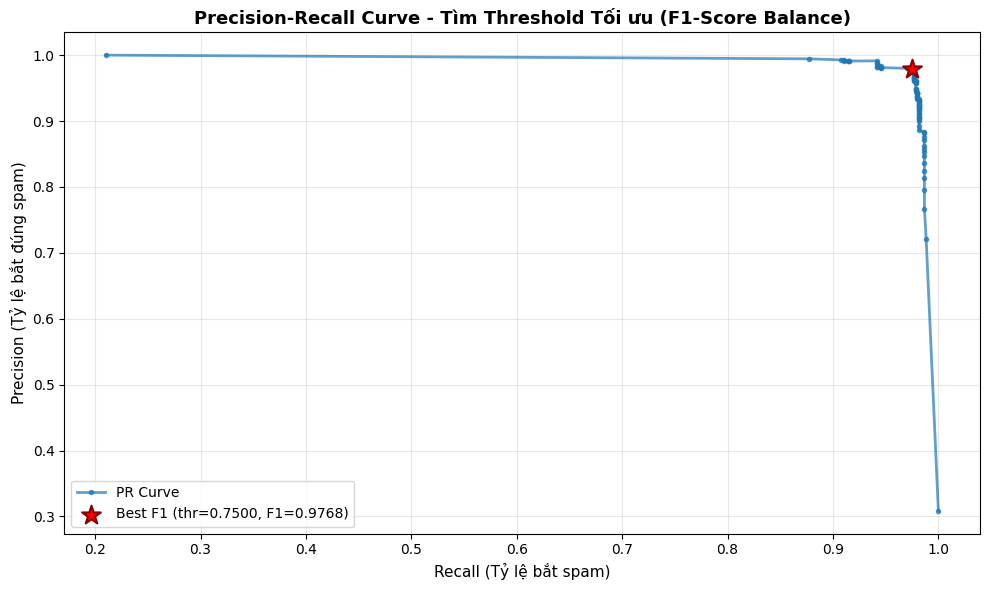


📈 TPA (True Positive Rate = Recall):
  Base: 0.9785
  Tuned: 0.9752
  ⚠️  GIẢM: -0.0033

📉 FPA (False Positive Rate = Bắt nhầm ham):
  Base: 0.0236
  Tuned: 0.0096
  ✅ GIẢM: 0.0140 (tốt hơn)


In [130]:
print("="*70)

# Tính precision, recall, f1_scores cho các threshold khác nhau (dùng tên không đụng biến scalar)
thresholds = np.linspace(0, 1, 101)
precision_list = []
recall_list = []
f1_scores_list = []
for thr in thresholds:
    preds_thr = (model.predict_proba(X_test) >= thr).astype(int)
    tp_l, tn_l, fp_l, fn_l = confusion_matrix(y_test, preds_thr)
    p = tp_l / (tp_l + fp_l + 1e-9)
    r = tp_l / (tp_l + fn_l + 1e-9)
    f1 = 2 * p * r / (p + r + 1e-9)
    precision_list.append(p)
    recall_list.append(r)
    f1_scores_list.append(f1)
precision_arr = np.array(precision_list)
recall_arr = np.array(recall_list)
f1_scores_arr = np.array(f1_scores_list)

# Tìm threshold tối ưu (F1-score lớn nhất)
best_idx = np.argmax(f1_scores_arr)
chosen_thr = thresholds[best_idx]

plt.figure(figsize=(10, 6))
plt.plot(recall_arr, precision_arr, marker='.', linewidth=2, label='PR Curve', alpha=0.7)
plt.scatter(recall_arr[best_idx], precision_arr[best_idx], 
           color='red', s=200, marker='*', zorder=5, edgecolors='darkred', linewidths=1.5,
           label=f'Best F1 (thr={chosen_thr:.4f}, F1={f1_scores_arr[best_idx]:.4f})')
plt.xlabel('Recall (Tỷ lệ bắt spam)', fontsize=11)
plt.ylabel('Precision (Tỷ lệ bắt đúng spam)', fontsize=11)
plt.title('Precision-Recall Curve - Tìm Threshold Tối ưu (F1-Score Balance)', fontsize=13, fontweight='bold')
plt.legend(fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Tính TPA (True Positive Rate) và FPA (False Positive Rate)
# Base (threshold=0.5)
tp_base, tn_base, fp_base, fn_base = confusion_matrix(y_test, (model.predict_proba(X_test) >= 0.5).astype(int))
accuracy_base = (tp_base + tn_base) / (tp_base + tn_base + fp_base + fn_base)
precision_base = tp_base / (tp_base + fp_base + 1e-9)
recall_base = tp_base / (tp_base + fn_base + 1e-9)
f1_base = 2 * precision_base * recall_base / (precision_base + recall_base + 1e-9)

tpa_base = recall_base
fpa_base = fp_base / (fp_base + tn_base + 1e-9)

# Tuned (chosen_thr)
tp_thr, tn_thr, fp_thr, fn_thr = confusion_matrix(y_test, (model.predict_proba(X_test) >= chosen_thr).astype(int))
accuracy_thr  = (tp_thr + tn_thr) / (tp_thr + tn_thr + fp_thr + fn_thr)
precision_thr = tp_thr / (tp_thr + fp_thr + 1e-9)
recall_thr    = tp_thr / (tp_thr + fn_thr + 1e-9)
f1_thr        = 2 * precision_thr * recall_thr / (precision_thr + recall_thr + 1e-9)

tpa_tuned = recall_thr
fpa_tuned = fp_thr / (fp_thr + tn_thr + 1e-9)

print(f"\n📈 TPA (True Positive Rate = Recall):")
print(f"  Base: {tpa_base:.4f}")
print(f"  Tuned: {tpa_tuned:.4f}")
if tpa_tuned > tpa_base:
    print(f"  ✅ TĂNG: +{tpa_tuned - tpa_base:.4f}")
else:
    print(f"  ⚠️  GIẢM: {tpa_tuned - tpa_base:.4f}")

print(f"\n📉 FPA (False Positive Rate = Bắt nhầm ham):")
print(f"  Base: {fpa_base:.4f}")
print(f"  Tuned: {fpa_tuned:.4f}")
if fpa_tuned < fpa_base:
    print(f"  ✅ GIẢM: {fpa_base - fpa_tuned:.4f} (tốt hơn)")
else:
    print(f"  ⚠️  TĂNG: {fpa_tuned - fpa_base:.4f}")


## Step 9 — Top Discriminative Words: Spam vs Ham
> Thay vì Loss Curve (CNB không dùng gradient descent), ta trực quan hóa **log-probability complement** của từng từ trong vocab.
> 
> - **Top Spam words**: từ mà model CNB học được là đặc trưng nhất cho spam (log-theta[spam] cao)  
> - **Top Ham words**: từ đặc trưng nhất cho ham
> 
> Đây chính là "trọng số" mà CNB học được — tương đương với feature importance của Logistic Regression.

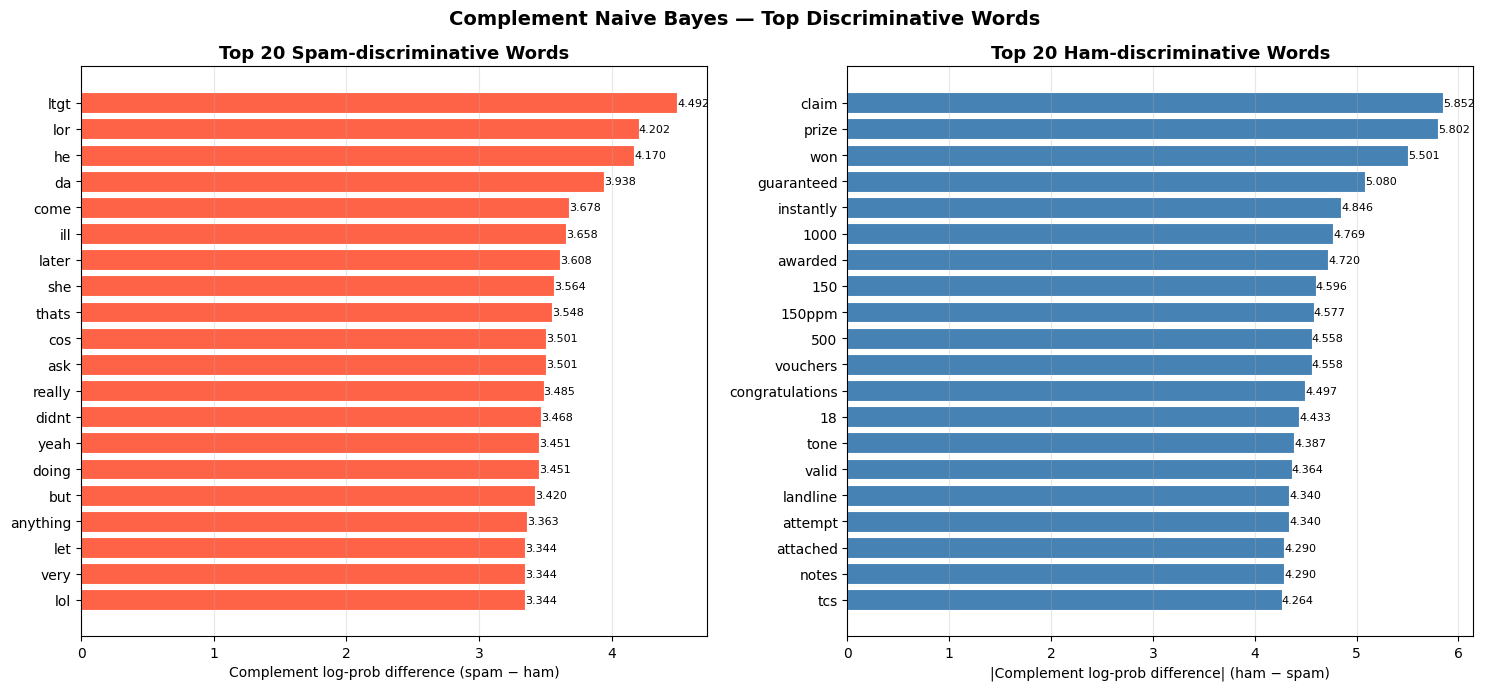

In [131]:
# Step 9: Top discriminative words — Spam vs Ham
# log_theta shape: (2, vocab_size), class 0=ham, class 1=spam
idx_to_word = {v: k for k, v in vectorizer.vocab.items()}

# Lấy log-theta của từng class
log_theta_ham  = model.log_theta[0]   # complement score cho ham
log_theta_spam = model.log_theta[1]   # complement score cho spam

# Discriminative score = log_theta_spam - log_theta_ham
# Giá trị dương → từ thiên về spam khi nhìn từ góc complement
disc_score = log_theta_spam - log_theta_ham

top_n = 20
top_spam_idx = np.argsort(disc_score)[-top_n:][::-1]   # score cao nhất → spam
top_ham_idx  = np.argsort(disc_score)[:top_n]           # score thấp nhất → ham

top_spam_words  = [idx_to_word[i] for i in top_spam_idx]
top_spam_scores = disc_score[top_spam_idx]

top_ham_words  = [idx_to_word[i] for i in top_ham_idx]
top_ham_scores = disc_score[top_ham_idx]

# --- Plot ---
fig, axes = plt.subplots(1, 2, figsize=(15, 7))

# Spam words
bars = axes[0].barh(top_spam_words[::-1], top_spam_scores[::-1],
                    color='tomato', edgecolor='white', linewidth=0.8)
axes[0].set_title(f'Top {top_n} Spam-discriminative Words', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Complement log-prob difference (spam − ham)', fontsize=10)
axes[0].grid(axis='x', alpha=0.3)
for bar, score in zip(bars, top_spam_scores[::-1]):
    axes[0].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{score:.3f}', va='center', fontsize=8)

# Ham words
bars2 = axes[1].barh(top_ham_words[::-1], np.abs(top_ham_scores[::-1]),
                     color='steelblue', edgecolor='white', linewidth=0.8)
axes[1].set_title(f'Top {top_n} Ham-discriminative Words', fontsize=13, fontweight='bold')
axes[1].set_xlabel('|Complement log-prob difference| (ham − spam)', fontsize=10)
axes[1].grid(axis='x', alpha=0.3)
for bar, score in zip(bars2, top_ham_scores[::-1]):
    axes[1].text(bar.get_width() + 0.001, bar.get_y() + bar.get_height()/2,
                 f'{abs(score):.3f}', va='center', fontsize=8)

plt.suptitle('Complement Naive Bayes — Top Discriminative Words', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## Step 10 — So sánh Confusion Matrix — Base vs Threshold Tuned

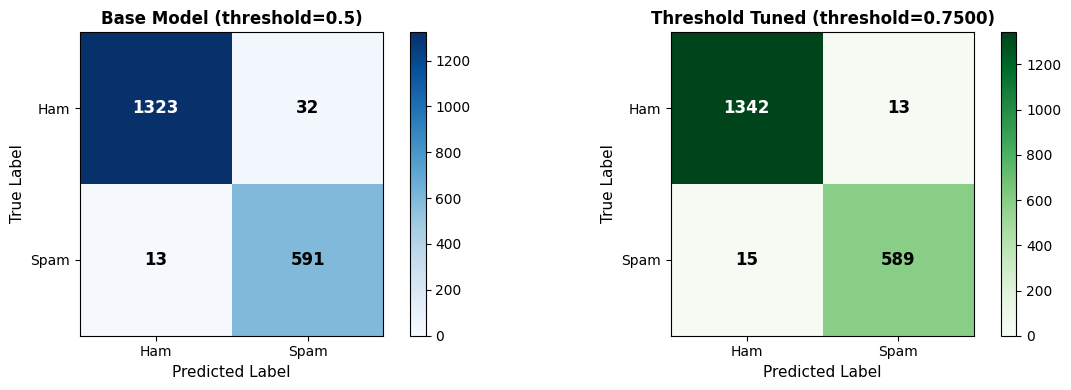


CONFUSION MATRIX COMPARISON
Metric               Base Model           Threshold Tuned     
------------------------------------------------------------
Accuracy             0.9770               0.9857
Precision            0.9486               0.9784
Recall               0.9785               0.9752
F1-score             0.9633               0.9768


In [132]:
# Step 10: So sánh Confusion Matrix — Base Model (thr=0.5) vs Threshold Tuned
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Base model
cm_base = np.array([[tn, fp], [fn, tp]])
im1 = axes[0].imshow(cm_base, cmap='Blues', vmin=0, vmax=cm_base.max())
axes[0].set_title("Base Model (threshold=0.5)", fontsize=12, fontweight='bold')
axes[0].set_xticks([0, 1]); axes[0].set_yticks([0, 1])
axes[0].set_xticklabels(['Ham', 'Spam'])
axes[0].set_yticklabels(['Ham', 'Spam'])
axes[0].set_ylabel("True Label", fontsize=11)
axes[0].set_xlabel("Predicted Label", fontsize=11)
for i in range(2):
    for j in range(2):
        axes[0].text(j, i, cm_base[i, j], ha='center', va='center', fontsize=12,
                     fontweight='bold',
                     color='white' if cm_base[i, j] > cm_base.max()/2 else 'black')
plt.colorbar(im1, ax=axes[0])

# Threshold tuned
cm_thr = np.array([[tn_thr, fp_thr], [fn_thr, tp_thr]])
im2 = axes[1].imshow(cm_thr, cmap='Greens', vmin=0, vmax=cm_thr.max())
axes[1].set_title(f"Threshold Tuned (threshold={chosen_thr:.4f})", fontsize=12, fontweight='bold')
axes[1].set_xticks([0, 1]); axes[1].set_yticks([0, 1])
axes[1].set_xticklabels(['Ham', 'Spam'])
axes[1].set_yticklabels(['Ham', 'Spam'])
axes[1].set_ylabel("True Label", fontsize=11)
axes[1].set_xlabel("Predicted Label", fontsize=11)
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm_thr[i, j], ha='center', va='center', fontsize=12,
                     fontweight='bold',
                     color='white' if cm_thr[i, j] > cm_thr.max()/2 else 'black')
plt.colorbar(im2, ax=axes[1])

plt.tight_layout()
plt.show()

# Tính các chỉ số cho threshold tối ưu
accuracy_thr  = (tp_thr + tn_thr) / (tp_thr + tn_thr + fp_thr + fn_thr)
precision_thr = tp_thr / (tp_thr + fp_thr + 1e-9)
recall_thr    = tp_thr / (tp_thr + fn_thr + 1e-9)
f1_thr        = 2 * precision_thr * recall_thr / (precision_thr + recall_thr + 1e-9)

# Nếu chưa có, tính lại các chỉ số cho threshold 0.5
if 'accuracy' not in locals() or 'precision' not in locals() or 'recall' not in locals() or 'f1' not in locals():
    tp, tn, fp, fn = confusion_matrix(y_test, (model.predict_proba(X_test) >= 0.5).astype(int))
    accuracy  = (tp + tn) / (tp + tn + fp + fn)
    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)

# Also compute explicit base scalars (use these for reporting)
# (These avoid any accidental ndarray/array collisions)
tp_base, tn_base, fp_base, fn_base = confusion_matrix(y_test, (model.predict_proba(X_test) >= 0.5).astype(int))
accuracy_base = (tp_base + tn_base) / (tp_base + tn_base + fp_base + fn_base)
precision_base = tp_base / (tp_base + fp_base + 1e-9)
recall_base = tp_base / (tp_base + fn_base + 1e-9)
f1_base = 2 * precision_base * recall_base / (precision_base + recall_base + 1e-9)

# Summary table
print("\n" + "="*60)
print("CONFUSION MATRIX COMPARISON")
print("="*60)
print(f"{'Metric':<20} {'Base Model':<20} {'Threshold Tuned':<20}")
print("-"*60)
print(f"{'Accuracy':<20} {accuracy_base:.4f}{'':>14} {accuracy_thr:.4f}")
print(f"{'Precision':<20} {precision_base:.4f}{'':>14} {precision_thr:.4f}")
print(f"{'Recall':<20} {recall_base:.4f}{'':>14} {recall_thr:.4f}")
print(f"{'F1-score':<20} {f1_base:.4f}{'':>14} {f1_thr:.4f}")
print("="*60)
